# 04 — Baselines: Direct FP32 (A0), Direct INT8, DCT, Low-Mel
Tất cả dùng **cùng classifier** của fold/seed. Payload DCT/Low-Mel = d giá trị INT8 (+4 byte header).

In [1]:
import sys, json, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import plotstyle; plotstyle.apply()
from plotstyle import SERIES, TEXT2, METHOD_COLORS
FIG = ROOT / 'results' / 'figures'; SUM = ROOT / 'results' / 'summary'; PRED = ROOT / 'results' / 'predictions'
LOGS = ROOT / 'results' / 'logs'
pd.set_option('display.float_format', '{:.4f}'.format)
from baselines import ZIGZAG, dct_keep, lowmel_keep, direct_int8, fit_dct_clip
from dataset import load_fold

## Thứ tự zig-zag và ví dụ tái tạo (fold 1)

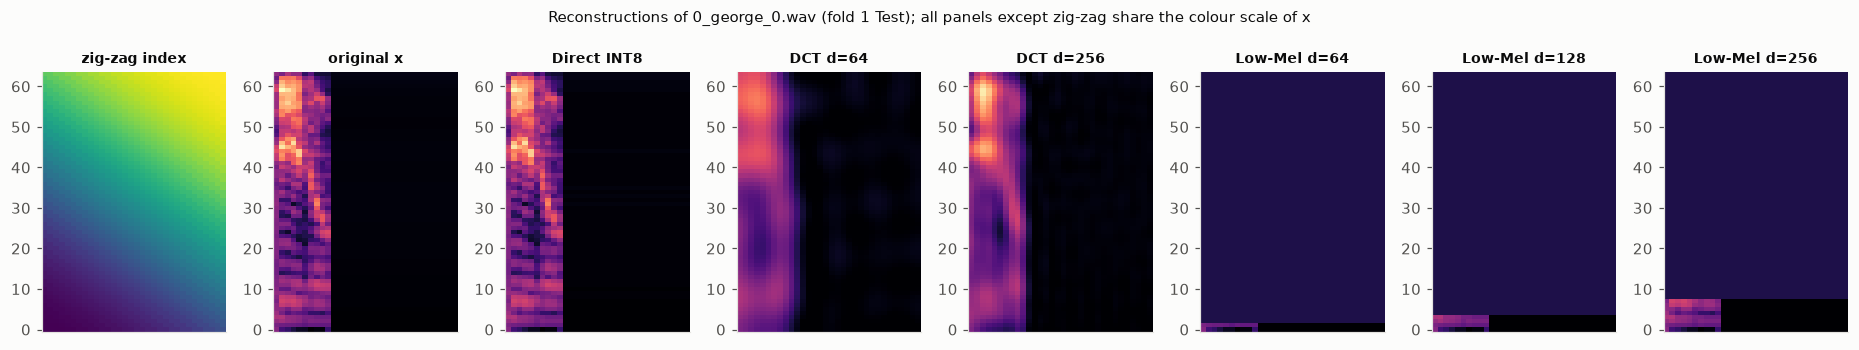

In [2]:
sp, mu, sigma = load_fold(1)
x = sp['test'].x[:1]
order = np.zeros((64, 32), int); order[ZIGZAG[:, 0], ZIGZAG[:, 1]] = np.arange(2048)
fig, axes = plt.subplots(1, 8, figsize=(17, 3.2))
panels = [('zig-zag index', order, 'viridis'), ('original x', x[0], 'magma'), ('Direct INT8', direct_int8(x)[0], 'magma')]
for d in (64, 256):
    panels.append((f'DCT d={d}', dct_keep(x, d, fit_dct_clip(sp['train'].x, d))[0], 'magma'))
for d in (64, 128, 256):
    panels.append((f'Low-Mel d={d}', lowmel_keep(x, d)[0], 'magma'))
vmin, vmax = x[0].min(), x[0].max()  # one colour scale for every reconstruction (scale of the original x)
for ax, (t, M, cm) in zip(axes, panels):
    kw = {} if t == 'zig-zag index' else dict(vmin=vmin, vmax=vmax)
    ax.imshow(M, origin='lower', aspect='auto', cmap=cm, **kw); ax.set_title(t, fontsize=9); ax.grid(False); ax.set_xticks([])
fig.suptitle(f"Reconstructions of {sp['test'].meta.filename.iloc[0]} (fold 1 Test); all panels except zig-zag share the colour scale of x", fontsize=10)
fig.tight_layout(); fig.savefig(FIG / 'baseline_reconstructions.png'); plt.show()

## Kết quả Test (từ `results/summary/results_summary.csv`, tạo bởi `src/evaluate.py`)

In [3]:
s = pd.read_csv(SUM / 'results_summary.csv')
b = s[(s.seed == 0) & s.method.isin(['Original', 'INT8', 'DCT', 'Low-Mel'])]
display(b.pivot_table(index=['method', 'd', 'bytes'], columns='test_speaker', values='Accuracy'))
b.groupby(['method', 'd', 'bytes'])[['Accuracy', 'Macro_F1', 'Delta_A_pp', 'R_acc', 'MSE', 'PRD_spec']].mean()

test_speaker         george  jackson  lucas  nicolas   theo  yweweler
method   d    bytes                                                  
DCT      64   68     0.3700   0.4060 0.1560   0.2060 0.3920    0.3800
         128  132    0.5000   0.5060 0.2040   0.2200 0.4660    0.4520
         256  260    0.5080   0.5360 0.2320   0.2440 0.4820    0.4940
INT8     2048 2052   0.5120   0.5620 0.2380   0.2680 0.4360    0.5180
Low-Mel  64   68     0.1000   0.1000 0.1000   0.1000 0.1000    0.1000
         128  132    0.1000   0.1000 0.1000   0.1000 0.1100    0.1000
         256  260    0.1000   0.1000 0.1000   0.1000 0.1380    0.1000
Original 2048 8196   0.5140   0.5620 0.2400   0.2700 0.4380    0.5160

Accuracy  Macro_F1  Delta_A_pp    R_acc    MSE  PRD_spec
method   d    bytes                                                          
DCT      64   68       0.3183    0.2576    -10.5000  74.7773 0.1318   32.9253
         128  132      0.3913    0.3474     -3.2000  91.2972 0.0829   26.5764
         256  260      0.4160    0.3705     -0.7333  97.8376 0.0539   21.9071
INT8     2048 2052     0.4223    0.3718     -0.1000  99.6613 0.0003    1.7652
Low-Mel  64   68       0.1000    0.0182    -32.3333  26.3606 0.9917   94.6931
         128  132      0.1017    0.0201    -32.1667  26.7411 0.9599   91.2874
         256  260      0.1063    0.0228    -31.7000  27.8065 0.8962   83.8391
Original 2048 8196     0.4233    0.3732      0.0000 100.0000 0.0000    0.0000